# HW1

In [1]:
import sys, subprocess, torch

REPO = "."
if REPO not in sys.path:
    sys.path.append(REPO)

arch = torch.cuda.get_arch_list()
cc = torch.cuda.get_device_capability(0)
sm = f"sm_{cc[0]}{cc[1]}"
print(f"torch {torch.__version__}, сборка под: {arch}")
print(f"GPU: {torch.cuda.get_device_name(0)}, {sm}")


x = torch.randn(8, 8, device="cuda")
_ = (x @ x).sum().item()

torch 2.5.1+cu121, сборка под: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
GPU: NVIDIA GeForce GTX 1050, sm_61


In [2]:
import json, random, time, threading
from pathlib import Path

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

from models import ConvNN
from equations import flops, memory, bytes_moved, latency, energy
from equations import _walk, _layer_flops, _layer_bytes
from torch import nn

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False

DEVICE, DTYPE = "cuda", torch.float32
RESULTS = Path("results_GTX1050"); (RESULTS / "figures").mkdir(parents=True, exist_ok=True)
model = ConvNN().to(DEVICE).eval()

_p = torch.cuda.get_device_properties(0)
ENV = {"gpu": _p.name,
       "total_memory": _p.total_memory,
       "sm_count": _p.multi_processor_count,
       "torch": torch.__version__, "cuda": torch.version.cuda,
       "cudnn": torch.backends.cudnn.version()}
json.dump(ENV, open(RESULTS / "env.json", "w"), indent=2)
ENV

{'gpu': 'NVIDIA GeForce GTX 1050',
 'total_memory': 4230086656,
 'sm_count': 5,
 'torch': '2.5.1+cu121',
 'cuda': '12.1',
 'cudnn': 90100}

## Сетка

In [3]:
SEED = 0
rng = random.Random(SEED)
S_BASE = [32, 64, 128, 224, 256, 384, 512]
B_BASE = [1, 2, 4, 8, 16, 32, 64, 128, 256]
S_EXTRA = rng.sample([s for s in range(32, 513, 16) if s not in S_BASE], 4)
B_EXTRA = rng.sample([b for b in range(1, 257) if b & (b - 1)], 3)

GRID = [{"S": s, "B": b, "is_validation": s in S_EXTRA or b in B_EXTRA}
        for s in sorted(S_BASE + S_EXTRA) for b in sorted(B_BASE + B_EXTRA)]
print(len(GRID), "конфигураций, валидационных:", sum(g["is_validation"] for g in GRID))

132 конфигураций, валидационных: 69


## Функции замера

In [4]:
import pynvml
pynvml.nvmlInit(); H = pynvml.nvmlDeviceGetHandleByIndex(0)

try:
    pynvml.nvmlDeviceGetPowerUsage(H)
    HAS_POWER = True
    power_w = lambda: pynvml.nvmlDeviceGetPowerUsage(H) / 1000.0
except pynvml.NVMLError:
    HAS_POWER = False
    power_w = None
print("датчик мощности:", "есть" if HAS_POWER else "нет")


def measure_memory(S, B):
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    x = torch.randn(B, 3, S, S, device=DEVICE, dtype=DTYPE)
    with torch.inference_mode():
        model(x)
    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated()
    del x; torch.cuda.empty_cache()
    return {"peak_allocated": peak}


def measure_latency(S, B, warmup=10, n_min=10, n_max=50, budget_s=2.0):
    x = torch.randn(B, 3, S, S, device=DEVICE, dtype=DTYPE)
    with torch.inference_mode():
        for _ in range(warmup):
            model(x)
        torch.cuda.synchronize()
        t, start = [], time.perf_counter()
        while len(t) < n_max:
            t0 = time.perf_counter(); model(x); torch.cuda.synchronize()
            t.append(time.perf_counter() - t0)
            if len(t) >= n_min and time.perf_counter() - start > budget_s:
                break
    del x; torch.cuda.empty_cache()
    return {"latency_median_s": float(np.median(t)), "latency_n": len(t)}


def measure_energy(S, B, target_s=3.0, hz=100):
    if not HAS_POWER:
        return {"energy_j": np.nan}
    x = torch.randn(B, 3, S, S, device=DEVICE, dtype=DTYPE)
    with torch.inference_mode():
        for _ in range(10):
            model(x)
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(5):
            model(x)
        torch.cuda.synchronize()
        n = max(10, int(target_s / ((time.perf_counter() - t0) / 5)))

        s, stop = [], threading.Event()
        def poll():
            while not stop.is_set():
                s.append((time.perf_counter(), power_w())); time.sleep(1 / hz)
        th = threading.Thread(target=poll, daemon=True); th.start()
        t_a = time.perf_counter()
        for _ in range(n):
            model(x)
        torch.cuda.synchronize(); t_b = time.perf_counter()
        stop.set(); th.join()
    del x; torch.cuda.empty_cache()

    seg = [q for q in s if t_a <= q[0] <= t_b]
    E = sum((seg[i+1][0] - seg[i][0]) * (seg[i][1] + seg[i+1][1]) / 2
            for i in range(len(seg) - 1))
    return {"energy_j": E / n}


def measure_idle_power(seconds=10.0, hz=50):
    if not HAS_POWER:
        return np.nan
    torch.cuda.synchronize(); torch.cuda.empty_cache()
    time.sleep(2)
    s, t_end = [], time.perf_counter() + seconds
    while time.perf_counter() < t_end:
        s.append(power_w()); time.sleep(1 / hz)
    return float(np.median(s))


P_IDLE = measure_idle_power()
print(f"P_idle = {P_IDLE}" + (" Вт" if HAS_POWER else " (нет датчика)"))

датчик мощности: нет
P_idle = nan (нет датчика)


## Прогон по сетке


In [5]:
OOM_MARKERS = ("out of memory", "CUDNN_STATUS_ALLOC_FAILED",
               "CUDNN_STATUS_NOT_SUPPORTED", "cuDNN error")


def is_oom(exc):
    """На карте с малым объёмом нехватка памяти приходит и как отказ cuDNN
    выделить воркспейс, а не только как OutOfMemoryError."""
    if isinstance(exc, torch.cuda.OutOfMemoryError):
        return True
    return isinstance(exc, RuntimeError) and any(m in str(exc) for m in OOM_MARKERS)


rows = []
for g in sorted(GRID, key=lambda g: g["S"] ** 2 * g["B"]):
    r = {**g, "oom": False}
    try:
        r |= measure_memory(g["S"], g["B"])
        r |= measure_latency(g["S"], g["B"])
        r |= measure_energy(g["S"], g["B"])
        e = r["energy_j"]
        print(f"S={g['S']:4d} B={g['B']:4d}  {r['latency_median_s']*1e3:8.2f} ms "
              f"{r['peak_allocated']/2**20:8.1f} MiB "
              + (f"{e*1e3:7.2f} mJ" if np.isfinite(e) else "      — mJ"))
    except Exception as exc:
        if not is_oom(exc):
            raise
        r["oom"] = True
        print(f"S={g['S']:4d} B={g['B']:4d}  OOM ({type(exc).__name__})")
    finally:
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    rows.append(r)

df = pd.DataFrame(rows)
df.to_csv(RESULTS / "measurements.csv", index=False)
ok = df[~df.oom].copy()
print(f"\nпрошло {len(ok)}, OOM {df.oom.sum()} из {len(df)}")

S=  32 B=   1      0.59 ms     13.1 MiB       — mJ
S=  32 B=   2      0.52 ms     13.1 MiB       — mJ
S=  32 B=   4      0.86 ms     13.2 MiB       — mJ
S=  64 B=   1      0.98 ms     13.1 MiB       — mJ
S=  80 B=   1      0.61 ms     13.2 MiB       — mJ
S=  32 B=   8      0.83 ms     13.2 MiB       — mJ
S=  64 B=   2      0.82 ms     13.2 MiB       — mJ
S=  80 B=   2      0.84 ms     13.2 MiB       — mJ
S=  32 B=  16      1.10 ms     13.3 MiB       — mJ
S=  64 B=   4      0.97 ms     17.9 MiB       — mJ
S= 128 B=   1      0.88 ms     13.3 MiB       — mJ
S=  80 B=   4      1.05 ms     23.2 MiB       — mJ
S=  32 B=  32      1.22 ms     14.2 MiB       — mJ
S=  64 B=   8      1.19 ms     18.5 MiB       — mJ
S= 128 B=   2      1.23 ms     14.2 MiB       — mJ
S= 208 B=   1      1.26 ms     14.9 MiB       — mJ
S= 224 B=   1      1.44 ms     15.3 MiB       — mJ
S=  80 B=   8      1.38 ms     24.1 MiB       — mJ
S=  32 B=  64      1.91 ms     16.3 MiB       — mJ
S=  64 B=  16      1.71 ms     

## Калибровка θ

In [8]:
P_PEAK = _p.multi_processor_count * 128 * 2 * 1.911e9   # Pascal: 128 ядер FP32 на SM
BW_PEAK = 112e9                                        # 128-бит GDDR5 @ 7 Гбит/с
K = 17

fit, val = ok[~ok.is_validation], ok[ok.is_validation]
F = flops(fit.S.values, fit.B.values)
y = fit.latency_median_s.values


def measure_bandwidth(n_bytes=64 * 2**20, n=50):
    a = torch.empty(n_bytes // 4, device=DEVICE, dtype=DTYPE)
    b = torch.empty_like(a)
    for _ in range(10):
        b.copy_(a)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n):
        b.copy_(a)
    torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    del a, b; torch.cuda.empty_cache()
    return 2 * n_bytes * n / dt


V_m = measure_bandwidth()
launch_corner = ok[ok.B * ok.S ** 2 <= 2e4]
t_0 = float(launch_corner.latency_median_s.min()) / K

res = minimize_scalar(
    lambda lg: np.mean((np.log(latency(fit.S.values, fit.B.values, (t_0, 10 ** lg, V_m)))
                        - np.log(y)) ** 2),
    bounds=(9, np.log10(P_PEAK)), method="bounded")
V_c = 10 ** res.x
theta = (t_0, V_c, V_m)

print(f"P_peak (расчёт) = {P_PEAK/1e12:.2f} ТФЛОП/с")
print(f"t_0 = {t_0*1e6:7.2f} мкс/ядро   (минимум по {len(launch_corner)} точкам launch-угла)")
print(f"V_m = {V_m/1e9:7.1f} ГБ/с       (измерено; {V_m/BW_PEAK:5.1%} от паспорта)")
print(f"V_c = {V_c/1e12:7.2f} ТФЛОП/с    (подогнано; {V_c/P_PEAK:5.1%} от паспорта)")
if V_c > P_PEAK * 0.999:
    print("!! V_c упёрся в паспортный пик -> модель или замеры не в порядке")

if HAS_POWER and np.isfinite(ok.energy_j).any():
    lat_fit = latency(fit.S.values, fit.B.values, theta)
    e_flop = max(0.0, float(F @ (fit.energy_j.values - P_IDLE * lat_fit) / (F @ F)))
    theta_energy = (P_IDLE, e_flop, 0.0, theta)
    print(f"\nP_idle = {P_IDLE:.1f} Вт, e_flop = {e_flop*1e12:.3f} пДж/FLOP")
else:
    theta_energy = None
    print("\nэнергия не калибруется: у карты нет датчика мощности")

json.dump({"model": "per-layer roofline: K*t_0 + sum_l max(F_l/V_c, M_l/V_m)",
           "theta_latency": {"t_0_s": t_0, "V_c_flops": V_c, "V_m_bytes": V_m},
           "theta_energy": (None if theta_energy is None else
                            {"P_idle_w": P_IDLE, "e_flop_j": theta_energy[1], "e_byte_j": 0.0}),
           "n_kernels": K, "P_peak": P_PEAK, "BW_peak": BW_PEAK,
           "epsilon_compute": V_c / P_PEAK, "epsilon_memory": V_m / BW_PEAK,
           "seed": SEED, "env": ENV},
          open(RESULTS / "theta.json", "w"), indent=2)

P_peak (расчёт) = 2.45 ТФЛОП/с
t_0 =   30.57 мкс/ядро   (минимум по 11 точкам launch-угла)
V_m =    84.5 ГБ/с       (измерено; 75.4% от паспорта)
V_c =    1.14 ТФЛОП/с    (подогнано; 46.8% от паспорта)

энергия не калибруется: у карты нет датчика мощности


In [9]:
PRED = {
    "Memory":  (lambda S, B: memory(S, B),         "peak_allocated",   "байт"),
    "Latency": (lambda S, B: latency(S, B, theta), "latency_median_s", "с"),
}
if theta_energy is not None:
    PRED["Energy"] = (lambda S, B: energy(S, B, theta_energy), "energy_j", "Дж")
NAMES = tuple(PRED)


def mape(pred, meas):
    return 100 * np.mean(np.abs((pred - meas) / meas))


print(f"{'величина':<10} {'единицы':>8} {'fit MAPE':>10} {'val MAPE':>10} {'val max':>10}")
for name in NAMES:
    pred, col, unit = PRED[name]
    pf, pv = pred(fit.S.values, fit.B.values), pred(val.S.values, val.B.values)
    mf, mv = fit[col].values, val[col].values
    print(f"{name:<10} {unit:>8} {mape(pf, mf):9.2f}% {mape(pv, mv):9.2f}% "
          f"{100*np.max(np.abs((pv-mv)/mv)):9.1f}%")

величина    единицы   fit MAPE   val MAPE    val max
Memory         байт     47.54%     40.37%      77.4%
Latency           с      8.25%      6.37%      24.6%


## Графики

In [10]:
S_CURVE = np.arange(32, 513, 16)                                   # сетка для кривых
B_CURVE = np.unique(np.round(np.logspace(0, 8, 40, base=2)).astype(int))


def plot_quantity(name):
    """Срезы по B, срезы по S и поверхность над (S, B): замеры и модель вместе."""
    pred, col, unit = PRED[name]
    fig = plt.figure(figsize=(16, 4.8))

    ax = fig.add_subplot(1, 3, 1)
    for S in S_BASE:
        sub = ok[ok.S == S].sort_values("B")
        if sub.empty:
            continue
        ln, = ax.plot(sub.B, sub[col], "o", ms=5, label=f"S={S} px")
        ax.plot(B_CURVE, pred(S, B_CURVE), "-", lw=1.2, color=ln.get_color(), alpha=.75)
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_xlabel("размер батча B [образцы]"); ax.set_ylabel(f"{name} [{unit}]")
    ax.set_title(f"{name}: срезы по B"); ax.grid(alpha=.3, which="both")
    ax.legend(fontsize=7, ncol=2)

    ax = fig.add_subplot(1, 3, 2)
    for B in B_BASE:
        sub = ok[ok.B == B].sort_values("S")
        if sub.empty:
            continue
        ln, = ax.plot(sub.S, sub[col], "o", ms=5, label=f"B={B}")
        ax.plot(S_CURVE, pred(S_CURVE, B), "-", lw=1.2, color=ln.get_color(), alpha=.75)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(S_BASE); ax.set_xticklabels(S_BASE, fontsize=8); ax.minorticks_off()
    ax.set_xlabel("сторона изображения S [px]"); ax.set_ylabel(f"{name} [{unit}]")
    ax.set_title(f"{name}: срезы по S"); ax.grid(alpha=.3, which="both")
    ax.legend(fontsize=7, ncol=2)

    ax = fig.add_subplot(1, 3, 3, projection="3d")
    SS, BB = np.meshgrid(S_CURVE, B_CURVE)
    ax.plot_surface(SS, np.log2(BB), np.log10(pred(SS, BB)), cmap="viridis",
                    alpha=.55, linewidth=0, rstride=2, cstride=2)
    ax.scatter(ok.S, np.log2(ok.B), np.log10(ok[col]), c="crimson", s=14,
               depthshade=False, label="замер")
    ax.set_xlabel("S [px]"); ax.set_ylabel("log2 B")
    ax.set_zlabel(f"log10 {name} [{unit}]")
    ax.set_title(f"{name}: поверхность модели"); ax.legend(fontsize=7)

    fig.suptitle(f"{name}: точки — измерено, линии и поверхность — модель", y=1.02)
    fig.tight_layout()
    fig.savefig(RESULTS / "figures" / f"{name.lower()}_vs_grid.png", dpi=150,
                bbox_inches="tight")


def plot_parity():
    """Предсказано против измеренного; калибровочные и валидационные точки отдельно."""
    fig, axes = plt.subplots(1, len(NAMES), figsize=(5 * len(NAMES), 4.6))
    for ax, name in zip(axes, NAMES):
        pred, col, unit = PRED[name]
        for sub, mk, lbl in [(ok[~ok.is_validation], "o", "калибровка"),
                             (ok[ok.is_validation], "^", "валидация")]:
            ax.loglog(sub[col], pred(sub.S.values, sub.B.values), mk, ms=6,
                      alpha=.75, label=lbl)
        lim = [ok[col].min() * .7, ok[col].max() * 1.4]
        ax.plot(lim, lim, "k--", lw=1, label="y = x")
        for k in (1.2, 1 / 1.2):
            ax.plot(lim, [v * k for v in lim], "k:", lw=.6)
        ax.set_xlabel(f"измерено, {name} [{unit}]")
        ax.set_ylabel(f"предсказано, {name} [{unit}]")
        ax.grid(alpha=.3, which="both"); ax.legend(fontsize=8)
    fig.suptitle("Предсказание против замера (пунктир — коридор ±20%)", y=1.02)
    fig.tight_layout()
    fig.savefig(RESULTS / "figures" / "parity.png", dpi=150, bbox_inches="tight")


def plot_error_map():
    """Относительная ошибка по всей сетке — видно, где именно модель ломается."""
    fig, axes = plt.subplots(1, len(NAMES), figsize=(5 * len(NAMES), 4.6))
    for ax, name in zip(axes, NAMES):
        pred, col, unit = PRED[name]
        e = ok.assign(err=100 * (pred(ok.S.values, ok.B.values) - ok[col]) / ok[col])
        piv = e.pivot_table(index="B", columns="S", values="err")
        m = np.nanmax(np.abs(piv.values))
        im = ax.pcolormesh(np.arange(len(piv.columns) + 1),
                           np.arange(len(piv.index) + 1), piv.values,
                           cmap="RdBu_r", vmin=-m, vmax=m)
        ax.set_xticks(np.arange(len(piv.columns)) + .5)
        ax.set_xticklabels(piv.columns, rotation=90, fontsize=6)
        ax.set_yticks(np.arange(len(piv.index)) + .5)
        ax.set_yticklabels(piv.index, fontsize=6)
        ax.set_xlabel("S [px]"); ax.set_ylabel("B [образцы]")
        ax.set_title(f"{name}: (модель − замер)/замер")
        plt.colorbar(im, ax=ax, label="%")
    fig.suptitle("Относительная ошибка по сетке (S, B)", y=1.02)
    fig.tight_layout()
    fig.savefig(RESULTS / "figures" / "error_map.png", dpi=150, bbox_inches="tight")


def plot_oom():
    fig, ax = plt.subplots(figsize=(7, 5))
    for oom_flag, mk, lbl in [(False, "o", "прошло"), (True, "x", "OOM")]:
        sub = df[df.oom == oom_flag]
        if len(sub):
            ax.scatter(sub.S, sub.B, marker=mk, s=45, label=lbl)
    bound = [max([b for b in range(1, 257) if memory(s, b) < ENV["total_memory"]],
                 default=np.nan) for s in S_CURVE]
    ax.plot(S_CURVE, bound, "r-", lw=1.5, label="граница по memory()")
    ax.set_yscale("log", base=2)
    ax.set_xlabel("сторона изображения S [px]")
    ax.set_ylabel("размер батча B [образцы]")
    ax.set_title(f"Граница OOM: {ENV['gpu']}, {ENV['total_memory']/2**30:.1f} ГиБ")
    ax.legend(); ax.grid(alpha=.3)
    fig.tight_layout()
    fig.savefig(RESULTS / "figures" / "oom_boundary.png", dpi=150)


def plot_regimes():
    """Режимы на одной панели: достигнутая производительность от нагрузки."""
    t_0, V_c, V_m = theta
    F = flops(ok.S.values, ok.B.values)
    M = bytes_moved(ok.S.values, ok.B.values)
    ach = F / ok.latency_median_s.values
    work = (ok.B * ok.S ** 2).values
    w_split = V_c * K * t_0 / 17751

    n_launch = n_mem = n_comp = 0
    for S, B in zip(ok.S, ok.B):
        tc = tm = 0.0
        for layer, i_s, o_s in _walk(S, B):
            if isinstance(layer, nn.Flatten):
                continue
            fc = _layer_flops(layer, i_s, o_s) / V_c
            fm = _layer_bytes(layer, i_s, o_s) / V_m
            if fc >= fm:
                tc += fc
            else:
                tm += fm
        n_launch += K * t_0 >= max(tm, tc)
        n_mem += (tm > K * t_0) and (tm > tc)
        n_comp += (tc > K * t_0) and (tc >= tm)
    n_memory_bound = n_launch + n_mem

    fig, ax = plt.subplots(figsize=(9, 5.6))
    lo, hi = work.min() / 2, work.max() * 2
    ax.axvspan(lo, w_split, color="tab:blue", alpha=.07)
    ax.axvspan(w_split, hi, color="tab:green", alpha=.07)
    ax.axvline(w_split, ls=":", c="k", lw=1.2)

    ww = np.logspace(np.log10(lo), np.log10(hi), 200)
    ax.plot(ww, 17751 * ww / (K * t_0), "b--", lw=1.3,
            label=f"memory-bound: время = K·t_0 = {K*t_0*1e6:.0f} мкс")
    ax.axhline(V_c, c="k", lw=1.6, label=f"compute-bound: V_c = {V_c/1e12:.2f} ТФЛОП/с")
    sc = ax.scatter(work, ach, c=np.log2(ok.B), cmap="viridis", s=28, zorder=3)

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lo, hi); ax.set_ylim(ach.min() / 3, V_c * 2.5)
    ax.text(.14, .07, "memory-bound\nвремя не зависит\nот нагрузки",
            transform=ax.transAxes, ha="center", va="bottom",
            fontsize=9.5, color="tab:blue", weight="bold")
    ax.text(.72, .07, "compute-bound\nплато на V_c",
            transform=ax.transAxes, ha="center", va="bottom",
            fontsize=9.5, color="tab:green", weight="bold")
    ax.text(w_split * .88, ach.min() / 3 * 1.6, f"граница B·S² = {w_split:.0f}",
            rotation=90, fontsize=8, va="bottom", ha="right")
    ax.text(.985, .975,
            f"по модели {n_memory_bound} точек memory-bound, {n_comp} compute-bound\n"
            f"в memory-bound области время определяют {K} запусков ядер,\n"
            f"а не трафик DRAM: он не доминирует ни в одной конфигурации",
            transform=ax.transAxes, ha="right", va="top", fontsize=8.5, style="italic",
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=.9))
    ax.set_xlabel("нагрузка B·S² [образцы·px²]")
    ax.set_ylabel("достигнутая производительность F/t [FLOP/с]")
    ax.set_title("Режимы: точки — замер, линии — границы модели")
    ax.grid(alpha=.3, which="both"); ax.legend(fontsize=8, loc="center left")
    plt.colorbar(sc, ax=ax, label="log2 B")

    fig.tight_layout()
    fig.savefig(RESULTS / "figures" / "regimes.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

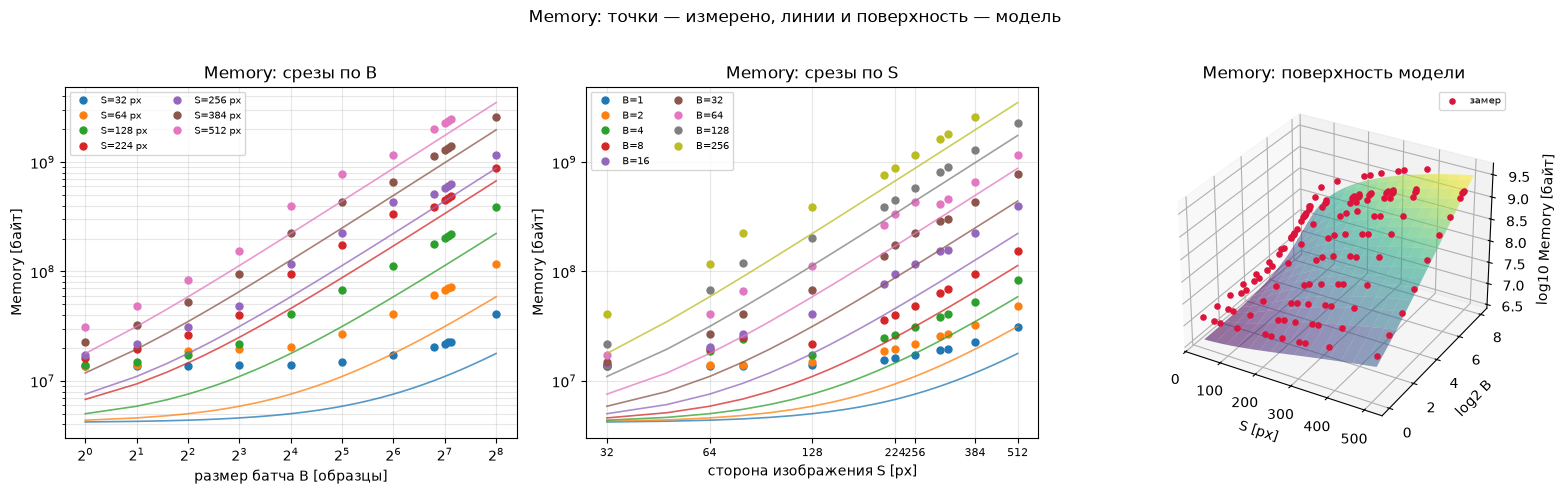

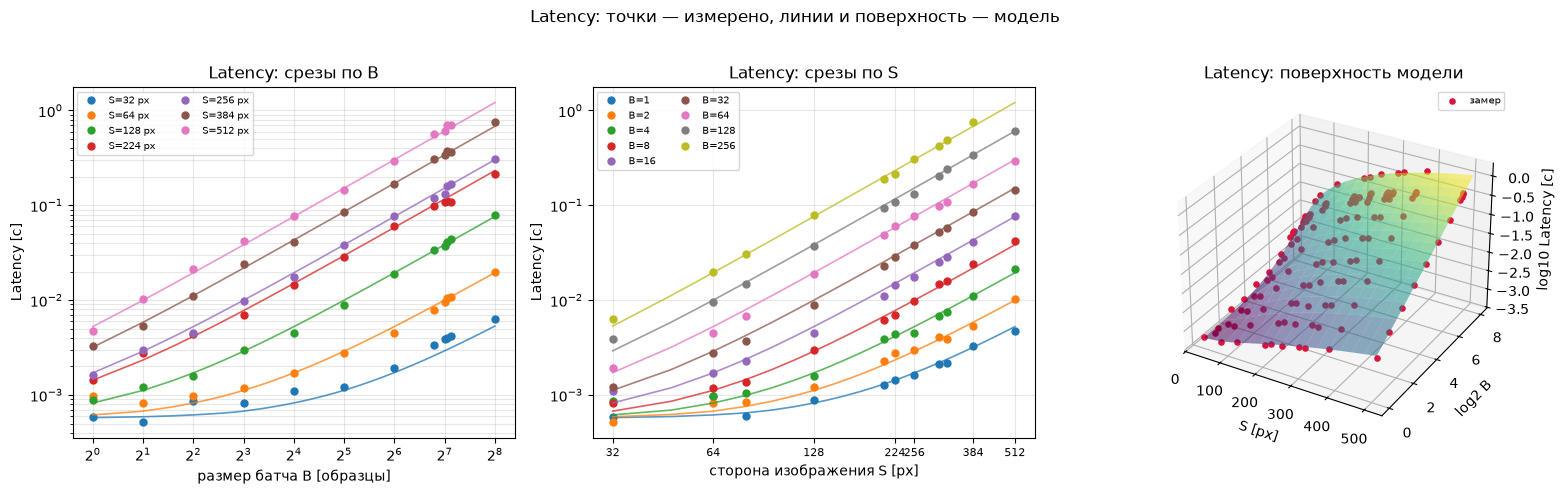

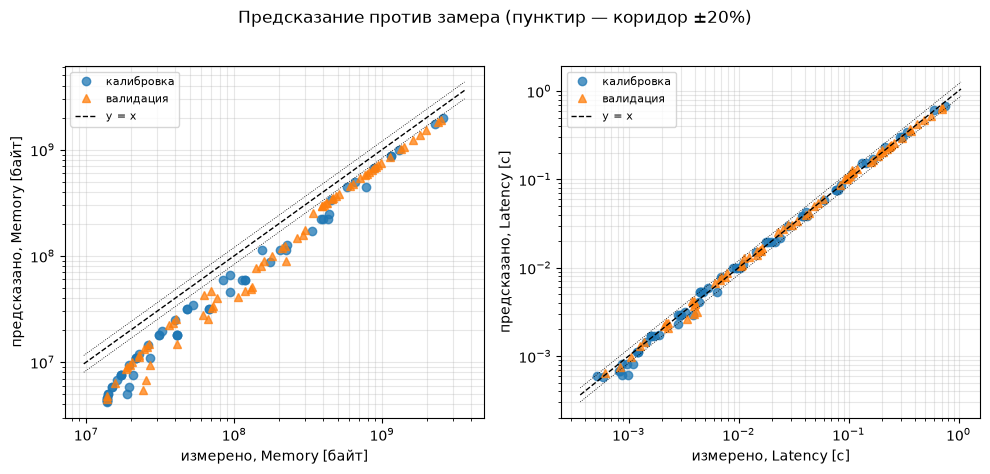

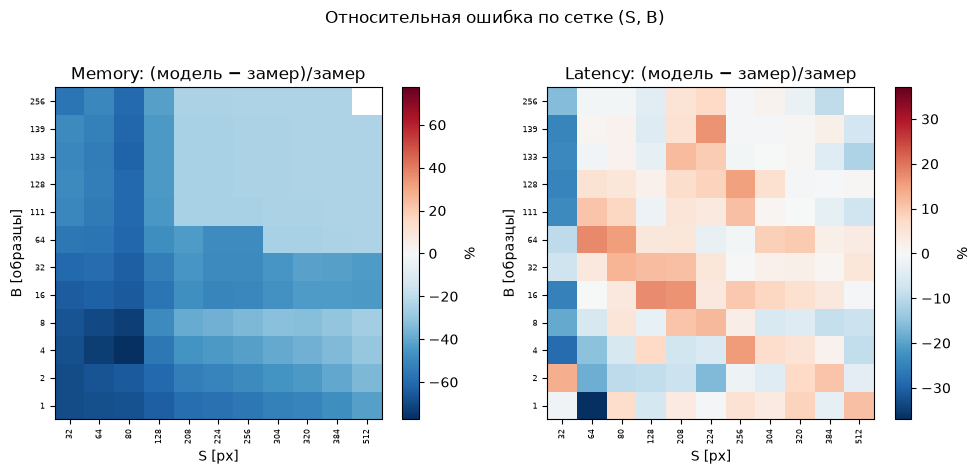

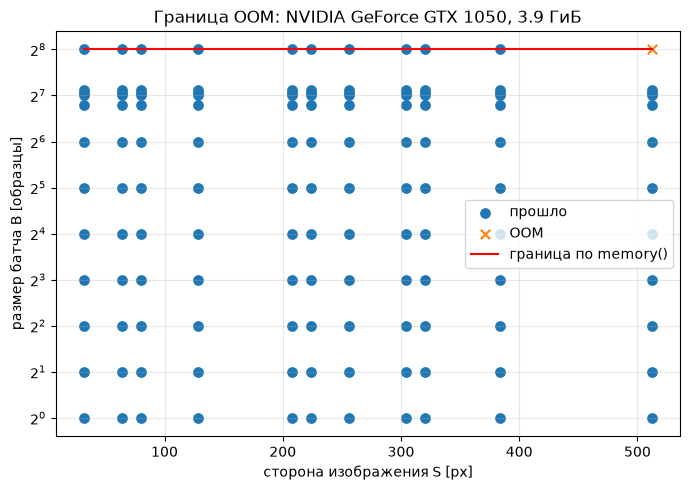

error_map.png                   73.6 КиБ
latency_vs_grid.png            383.2 КиБ
memory_vs_grid.png             396.6 КиБ
oom_boundary.png                56.4 КиБ
parity.png                     162.8 КиБ
regimes.png                    142.0 КиБ


In [11]:
for name in NAMES:
    plot_quantity(name)
plot_parity()
plot_error_map()
plot_oom()
plot_regimes()
plt.show()

for f in sorted((RESULTS / "figures").glob("*.png")):
    print(f"{f.name:28} {f.stat().st_size/1024:7.1f} КиБ")